# Ecommerce Retail Data 분석 프로젝트

## 1. 분석 목적 및 방향

- 판매 데이터를 기반으로 고객의 구매 패턴을 이해하고, 이탈 구간과 재구매 전환 포인트를 파악하여 매출 성장과 고객 유지 전략 수립에 활용하고자 함

- 첫 구매 고객의 월별 리텐션을 코호트 단위로 분석하여, 이탈이 가장 크게 발생하는 시점을 파악하고 향후 리텐션 개선 실험의 타겟 구간을 정의하는 것을 목적으로 함

## 2. 데이터 요약

- 기간: 2010-12 ~ 2011-12 (총 13개월)
- 단위: CustomerID 기준
- 리텐션 정의 : 특정 월에 첫 구매한 고객이 이후 N개월 차에 한 번 이상 구매한 비율

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [ ]:
from pathlib import Path

# 프로젝트 루트 기준 경로 설정
BASE_DIR = Path().resolve().parent
DATA_PATH = BASE_DIR / "data" / "online_retail.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
len(df)

541909

In [5]:
# 3. 데이터 전처리

# 3.1 변수명과 타입 일치 및 결측치 확인

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
# 전체 데이터 수 541909 / 결측치 존재 컬럼 -> Description, CustomerID
# CustomerID 없는 데이터는 제외 / Description 없는 데이터는 제외 보류
df = df[df['CustomerID'].notna()].copy()

# 결측치 제거 후 전체 데이터 수 확인 -> 406829
len(df)

406829

In [7]:
# 현재 CustomerID가 float64 타입인데 정수형으로 변경 가능한지 확인
# 모든 ID를 1로 나눈 나머지가 0인지 확인
is_integer_all = (df['CustomerID'] % 1 == 0).all()
print(f"모두 정수 형태인가요? : {is_integer_all}")

모두 정수 형태인가요? : True


In [8]:
# 테스트 결과 True -> CustomerID는 모두 정수형으로 변경 : int로 변환
df['CustomerID'] = df['CustomerID'].astype(int)
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [9]:
# 3.2 리텐션 분석을 위한 취소 데이터 모두 삭제

# 리텐션 분석의 정확성을 위해, 취소 및 반품으로 판단되는 거래(InvoiceNo가 ‘C’로 시작하거나 Quantity가 0 이하인 데이터)는 분석 대상에서 제외
# InvoiceNo 중 문자열로 된 데이터가 모두 C로 시작하는지(취소 및 반품 데이터인지) 확인

print(f"InvoiceNo의 데이터 타입은 : {df['InvoiceNo'].dtype}")
non_numeric_invoice = df[~df['InvoiceNo'].astype(str).str.isnumeric()]

total_cnt = len(df)
non_numeric_cnt = len(non_numeric_invoice)
numeric_cnt = total_cnt - non_numeric_cnt
cancel_invoice = df[df['InvoiceNo'].astype(str).str.startswith('C')]

print(f"전체 데이터 수: {total_cnt}")
print(f"숫자 InvoiceNo: {numeric_cnt}")
print(f"문자 포함 InvoiceNo: {non_numeric_cnt}")
print(f"문자 'C' 포함 InvoiceNo: {len(cancel_invoice)}")

non_numeric_invoice.head(3)

InvoiceNo의 데이터 타입은 : object
전체 데이터 수: 406829
숫자 InvoiceNo: 397924
문자 포함 InvoiceNo: 8905
문자 'C' 포함 InvoiceNo: 8905


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom


In [10]:
# Quantity가 0 이하인데 C가 아닌 경우도 확인 -> 없음

print(len(df[df['Quantity'] <= 0]))
df[(df['Quantity'] <= 0) & (~df['InvoiceNo'].astype(str).str.startswith('C'))].head()

8905


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [11]:
# InvoiceNo가 ‘C’로 시작하거나 Quantity가 0 이하인 데이터 제거

# 취소/반품 제거
df = df[(~df['InvoiceNo'].astype(str).str.startswith('C')) & (df['Quantity'] > 0)].copy()

print(f"정제 후 데이터 수: {len(df)}")


정제 후 데이터 수: 397924


In [12]:
# 3.3 월별 데이터 분석을 위한 날짜 데이터 전처리

print(df['InvoiceDate'].dtype)

# InvoiceDate 컬럼 데이터 타입이 Object 이므로 Datetime으로 변환 후 진행
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(df['InvoiceDate'].dtype)

object
datetime64[ns]


In [13]:
# InvoiceDate -> InvoiceMonth 추가(월별 데이터)
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
# 변환 내역 확인
df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,2010-12


In [14]:
df['InvoiceMonth'].nunique()
# 총 13개월 치 데이터가 존재하는 것을 확인 가능

13

In [15]:
### 4. 분석 설계

# 4.1 CohortMonth 만들기

cohort = (
    df.groupby('CustomerID')['InvoiceMonth']
      .min()
      .reset_index()
      .rename(columns={'InvoiceMonth': 'CohortMonth'})
)

# 원본 데이터에 CohortMonth 붙이기

df = df.merge(cohort, on='CustomerID', how='left')

df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth,CohortMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,2010-12,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,2010-12,2010-12


In [16]:
# 4.2 Cohort Index 계산하기

# 연/월 분리
invoice_year = df['InvoiceMonth'].dt.year
invoice_month = df['InvoiceMonth'].dt.month

cohort_year = df['CohortMonth'].dt.year
cohort_month = df['CohortMonth'].dt.month

# CohortIndex 계산
df['CohortIndex'] = ((invoice_year - cohort_year) * 12 + (invoice_month - cohort_month))

df.head(3)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth,CohortMonth,CohortIndex
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,2010-12,2010-12,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12,2010-12,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,2010-12,2010-12,0


In [17]:
df.tail(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth,CohortMonth,CohortIndex
397921,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,2011-12,2011-08,4
397922,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,2011-12,2011-08,4
397923,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680,France,2011-12,2011-08,4


In [18]:
# 4.3 Retention Matrix 설계
# 코호트별 고객 수 집계
cohort_data = (
    df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID']
      .nunique()
      .reset_index()
)

cohort_data

,CohortMonth,CohortIndex,CustomerID
0,2010-12,0,885
1,2010-12,1,324
2,2010-12,2,286
3,2010-12,3,340
4,2010-12,4,321
...,...,...,...
86,2011-10,1,86
87,2011-10,2,41
88,2011-11,0,324
89,2011-11,1,36


In [19]:
# Retention Matrix 형태로 피벗
# CohortIndex = 0 : 첫 구매가 발생한 월 (First Order Month)

cohort_pivot = cohort_data.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='CustomerID'
)
cohort_pivot

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN
2011-05,284.0,54.0,49.0,49.0,59.0,66.0,75.0,27.0,NaN,NaN,NaN,NaN,NaN
2011-06,242.0,42.0,38.0,64.0,56.0,81.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,188.0,34.0,39.0,42.0,51.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,169.0,35.0,42.0,41.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
# Retention 수치를 비율로 전환
retention = cohort_pivot.divide(cohort_pivot[0], axis=0)
retention

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,1.0,0.366102,0.323164,0.384181,0.362712,0.397740,0.362712,0.349153,0.353672,0.395480,0.374011,0.502825,0.265537
2011-01,1.0,0.220624,0.266187,0.230216,0.321343,0.287770,0.247002,0.242206,0.299760,0.326139,0.364508,0.117506,NaN
2011-02,1.0,0.186842,0.186842,0.284211,0.271053,0.247368,0.252632,0.278947,0.247368,0.305263,0.068421,NaN,NaN
2011-03,1.0,0.150442,0.252212,0.199115,0.223451,0.168142,0.267699,0.230088,0.278761,0.086283,NaN,NaN,NaN
2011-04,1.0,0.213333,0.203333,0.210000,0.196667,0.226667,0.216667,0.260000,0.073333,NaN,NaN,NaN,NaN
2011-05,1.0,0.190141,0.172535,0.172535,0.207746,0.232394,0.264085,0.095070,NaN,NaN,NaN,NaN,NaN
2011-06,1.0,0.173554,0.157025,0.264463,0.231405,0.334711,0.095041,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,1.0,0.180851,0.207447,0.223404,0.271277,0.111702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,1.0,0.207101,0.248521,0.242604,0.124260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


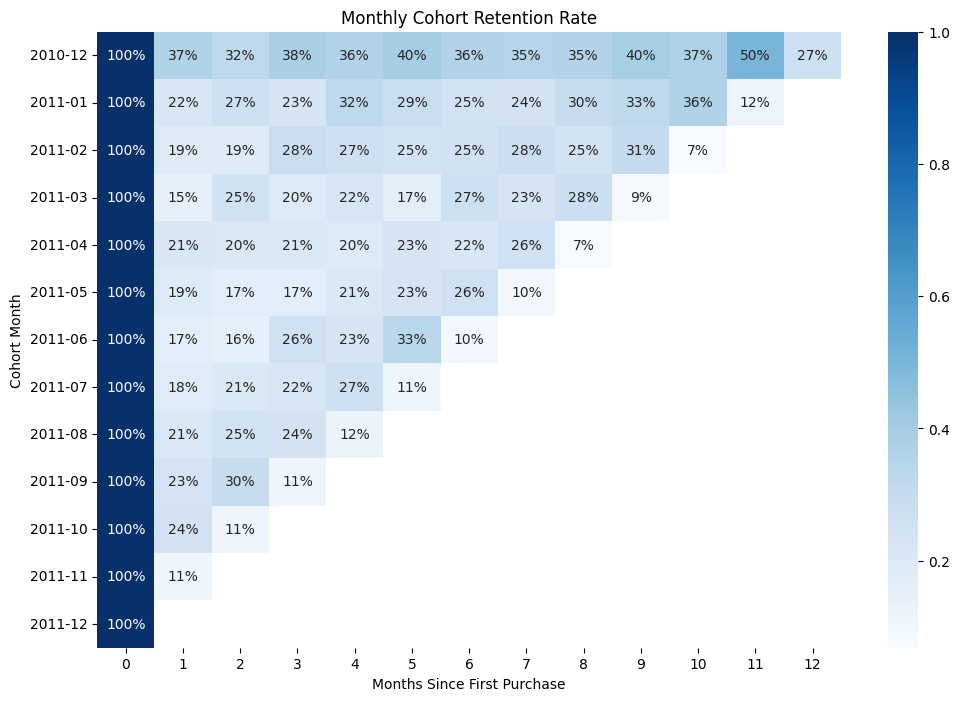

In [21]:
# 리텐션율 히트맵

plt.figure(figsize=(12, 8))
sns.heatmap(retention, annot=True, fmt=".0%", cmap="Blues", mask=retention.isna())
plt.title("Monthly Cohort Retention Rate") # 타이틀 : 첫 구매 기준 월별 고객 리텐션 코호트 분석
plt.ylabel("Cohort Month")                # Y 축 라벨 : 첫 구매 월 (Cohort Month)
plt.xlabel("Months Since First Purchase") # X 축 라벨 : 첫 구매 이후 경과 개월 (M0 = 첫 구매 월)
plt.show()

## 3.  데이터 패턴 및 분석
- 모든 구간에서 M1 리텐션이 가장 크게 하락
  - 대부분 0.13 ~ 0.38 수준 (100% -> 13% ~ 38% 수준)

- 초기 리텐션들의 경우 M2 이후는 유지되거나 오히려 반등되는 모습을 보임
    - 특히 [2010-12] 코호트의 경우 장기 리텐션이 상대적으로 높음
      - 초기 유입 고객의 질 또는 시즌성 영향 가능성

- 특이 사항
  - [2011-09] 코호트는 타 코호트 대비 상대적으로 높은 초기 리텐션(M1)을 보이며, M2 구간에서도 리텐션이 상승하는 모습을 보임
    - M1이 비교적 높고 M2에서 오히려 리텐션이 상승했다는 점에서 눈여겨 볼 필요가 있음
    - 다만 해당 코호트의 M3([2011-12])에서 리텐션이 급락하는 모습을 보이나, 이는 모든 코호트에서 [2011-12] 구간 리텐션이 일괄적으로 급락 현상 관측
      - 이는 최신 월 데이터가 아직 완전하게 수집되지 않았을 가능성(Right censoring)을 시사하며,[2011-12] 구간의 데이터 관측 범위를 확인한 이후 해석이 필요

In [22]:
# 4.4 가설 검증
# [2011-12] 구간 데이터 숫자 및 고객 수 타 구간과 비교

cohort_stats = (
    df.groupby('CohortMonth')
      .agg(
          customers=('CustomerID', 'nunique'), # 고객 수
          orders=('InvoiceNo', 'nunique'), # 주문 수
          rows=('CustomerID', 'count') # 거래 로그 수
      )
      .sort_index()
)

cohort_stats


,customers,orders,rows
CohortMonth,,,
2010-12,885,8320,169332
2011-01,417,2153,47775
2011-02,380,1562,30454
2011-03,452,1611,34274
2011-04,300,924,19246
2011-05,284,819,15682
2011-06,242,661,13870
2011-07,188,442,10534
2011-08,169,358,13009


In [23]:
# 대체적으로 고객 수와 주문 수가 점차 줄어드는 모습을 보이고 있지만 마지막 구간에서는 급락하는 모습을 보임
# 실제 데이터가 말일까지 작성이 되어 있는지 확인
df[df['InvoiceMonth'] == '2011-12']['InvoiceDate'].describe()

# 실제 확인 결과 [2011-12] 구간에서는 9일까지밖에 데이터가 없는 것을 확인 -> 완전히 데이터가 수집되지 않았음을 알 수 있다.

,InvoiceDate
count,17304
mean,2011-12-05 14:14:46.428571392
min,2011-12-01 08:33:00
25%,2011-12-04 11:24:00
50%,2011-12-05 16:28:00
75%,2011-12-07 12:55:00
max,2011-12-09 12:50:00


In [24]:
df[df['InvoiceMonth'] == '2011-12']['InvoiceDate'].dt.day.value_counts().sort_index()


,count
InvoiceDate,
1,2140
2,1979
4,1941
5,3374
6,2554
7,2167
8,2532
9,617


## 4. 특이사항 검증 및 해석

### [1] [2010-12] 코호트 : 장기 리텐션이 가장 우수한 구간

- 핵심 포인트
  - M1 이후에도 M2~M10 구간까지 타 코호트 대비 상대적으로 안정적이고 높은 리텐션을 유지
  - 단기 이벤트성 유입만으로는 설명하기 어려운 장기 잔존 패턴 관측

- 해석
  - 연말 시즌은 첫 구매 진입 장벽이 낮고, 구매 이후 제품 경험이 충분히 축적되기 좋은 시기
  - 이로 인해 단기 구매 고객과 함께 장기 재구매 가능성이 높은 고객이 동시에 유입되었을 가능성
  - 즉, 2010-12 코호트는 연말 쇼핑 시즌에 유입된 고객 중 일부가 이후에도 지속적인 재구매 고객으로 전환되어, 장기적으로 안정적인 리텐션을 형성한 코호트로 해석 가능


### [2] 2011-09 코호트 : 계절성 혹은 이벤트(크리스마스 대비)로 인한 수요 급증

- 핵심 포인트
  - M1 리텐션이 타 구간 대비 상대적으로 높은 모습을 보임
  - M2에서의 상승은 타 구간에서도 동일하게 관측
  - M3 급락(타 구간 동일 관측)은 데이터 미완전성으로인한 모습

- 해석
  - [2011-09] 코호트는 M1 리텐션이 상대적으로 높게 나타나, 초기 구매 의도가 명확한 고객 유입이 있었음을 시사
  - 한편, M2 구간에서 관측되는 리텐션 상승은 [2011-09] 코호트에 국한된 현상이 아니라 동일 시점의 다른 코호트에서도 공통적으로 나타난 패턴
    - 이는 특정 코호트의 특성보다는, 연말 쇼핑 시즌을 앞둔 수요 증가가 리텐션 전반에 영향을 미쳤을 가능성을 시사
    - 해당 패턴을 종합할 때, [2011-09] 구간은 크리스마스 시즌을 대비한 수요 증가의 영향을 받은 시점으로 해석 가능
    
---

## 5. 데이터 분석 시사점

- 전 코호트에 걸쳐 첫 구매 이후 1개월(M1) 구간에서 가장 큰 이탈이 발생

- 이는 장기 리텐션 저하의 주요 원인이 ‘재구매 빈도 부족’이 아니라, 첫 구매 이후 초기 경험 구간에서 재구매로 이어지지 못하는 구조에 있음을 시사

- 따라서 리텐션 개선의 핵심 타겟은 장기 고객 유지가 아닌, 첫 구매 이후 1개월 이내 고객을 대상으로 한 재구매 유도 전략(M1 Retention 개선)에 있음

- 향후 분석 및 실험은 M1 구간 고객의 구매 행동, 상품 구성, 구매 간격 등의 차이를 기반으로 재구매 전환을 유도할 수 있는 가설 수립 및 A/B 테스트로 확장 가능

---

## 6. M1 Retention 개선을 위한 가설 설계 및 검증

### 6.1 공통 레이어 설계

### 6.2 가설별 단변량 검증
- [1] 첫 구매 강도 가설
- [2] 초기 구매 빈도 가설
- [3] 초기 구매 카테고리 가설

### 6.3 다변량 검증 (Driver Analysis)
  - 로지스틱 회귀 모델 설계
  - 변수 투입 구조
  - Odds Ratio 해석
  - 가설별 영향력 평가

### 6.4 가설별 최종 결론 및 인사이트
  - 최종 결론
  - 주요 인사이트
  - 분석 한계

---
### [6.1] 분석 공통 Feature Layer 구축

In [25]:
# 대표 키워드 추출 및 정제

# Description 상위 빈도 50개
top_desc = (
    df['Description']
    .value_counts()
    .head(50)
    .reset_index()
)

top_desc.columns = ['Description', 'freq']
top_desc


,Description,freq
0,WHITE HANGING HEART T-LIGHT HOLDER,2028
1,REGENCY CAKESTAND 3 TIER,1724
2,JUMBO BAG RED RETROSPOT,1618
3,ASSORTED COLOUR BIRD ORNAMENT,1408
4,PARTY BUNTING,1397
5,LUNCH BAG RED RETROSPOT,1316
6,SET OF 3 CAKE TINS PANTRY DESIGN,1159
7,LUNCH BAG BLACK SKULL.,1105
8,POSTAGE,1099
9,PACK OF 72 RETROSPOT CAKE CASES,1068


In [26]:
from collections import Counter

# 상위 50개 Description에서 단어 분해
words = (
    top_desc['Description']
    .str.split()
    .explode()
)

word_freq = (
    words
    .value_counts()
    .reset_index()
)

word_freq.columns = ['word', 'freq']
word_freq.head(30)

,word,freq
0,BAG,15
1,LUNCH,9
2,RETROSPOT,8
3,JUMBO,8
4,SET,7
5,RED,7
6,OF,6
7,DESIGN,5
8,HEART,4
9,REGENCY,3


In [27]:
# 불용어 제거
stopwords = [
    '1','2','3','4','5','6','7','8','9','0',"50'S",'72',
    'SET', 'OF', 'THE', 'AND', 'WITH',
    'SMALL', 'LARGE', 'PACK',
    'WHITE', 'RED', 'BLUE', 'PINK', 'GREEN', 'YELLOW',
    'BLACK', 'IVORY', 'CREAM',
    'BOX', 'DESIGN','RETROSPOT','VINTAGE','REGENCY','PANTRY',
    'SUKI','SPACEBOY', 'KEEP','CALM','MAKING',
    'POSTAGE', 'CHRISTMAS', 'PARTY',
    'POLKADOT', 'SPOTTY', 'ASSORTED', 'COLOUR',
    'REX', 'CASH+CARRY', 'BAKELIKE',
    'KIT', 'CHAIN', 'CASES', 'TIER', 'PIECE', 'FINISH', 'PRINTED',
    'SKULL.', 'RABBIT', 'NIGHT', 'WOODLAND', 'CARS', 'APPLE'
]

word_freq_filtered = word_freq[
    ~word_freq['word'].isin(stopwords)
]

word_freq_filtered.head(50)

,word,freq
0,BAG,15
1,LUNCH,9
3,JUMBO,8
8,HEART,4
13,CAKE,3
15,PAPER,2
16,WICKER,2
18,BUNTING,2
19,HANGING,2
20,TINS,2


In [28]:
# 카테고리 컬럼 추가

# 키워드 → 카테고리 매핑 사전
keyword_to_category = {

    # Bags & Carry
    'BAG': 'Bags & Carry',
    'LUNCH': 'Bags & Carry',
    'SHOPPER': 'Bags & Carry',
    'JUMBO': 'Bags & Carry',

    # Kitchenware
    'CAKE': 'Kitchenware',
    'BAKING': 'Kitchenware',
    'MOULDS': 'Kitchenware',
    'RECIPE': 'Kitchenware',
    'JAM': 'Kitchenware',
    'JELLY': 'Kitchenware',

    # Tableware
    'TEA': 'Tableware',
    'TEACUP': 'Tableware',
    'SAUCER': 'Tableware',
    'BOWLS': 'Tableware',
    'CAKESTAND': 'Tableware',

    # Lighting
    'T-LIGHT': 'Lighting',
    'LIGHT': 'Lighting',
    'LAMP': 'Lighting',
    'HOLDER': 'Lighting',

    # Storage & Organization
    'TINS': 'Storage & Organization',
    'JARS': 'Storage & Organization',
    'STORAGE': 'Storage & Organization',
    'LID': 'Storage & Organization',

    # Home Decor
    'HEART': 'Home Decor',
    'FRAME': 'Home Decor',
    'PICTURE': 'Home Decor',
    'BIRD': 'Home Decor',
    'ORNAMENT': 'Home Decor',
    'BUNTING': 'Home Decor',
    'CHALKBOARD': 'Home Decor',
    'HANGING': 'Home Decor',
    'ROSES': 'Home Decor',
    'PAISLEY': 'Home Decor'
}

# 카테고리 우선순위
category_priority = [
    'Bags & Carry',
    'Kitchenware',
    'Tableware',
    'Lighting',
    'Storage & Organization',
    'Home Decor'
]


# Description → Category 매핑 함수
def map_category(description):

    if pd.isna(description):
        return 'Other'

    tokens = description.upper().split()

    for category in category_priority:
        for token in tokens:
            if keyword_to_category.get(token) == category:
                return category

    return 'Other'


# Category 컬럼 생성 (df 가장 상단에서 실행)
df['category'] = df['Description'].apply(map_category)

In [29]:
# 고객 id 기준 데이터 프레임 생성
customer_master = df[['CustomerID']].drop_duplicates()

# m1 기간 리텐션 여부 체크
m1_flag = (
    df[df['CohortIndex'] == 1]['CustomerID']
    .drop_duplicates()
    .to_frame()
)

m1_flag['M1_Retention'] = 1

# merge
customer_master = customer_master.merge(
    m1_flag,
    on='CustomerID',
    how='left'
)

customer_master['M1_Retention'] = customer_master['M1_Retention'].fillna(0).astype(int)
# 실제 총 유저 수와 비교
print(f"실제 총 유저 수는 {df['CustomerID'].nunique()}명 입니다")
print(f"공통 데이터프레임 유저 수 :  {len(customer_master)}")
customer_master

실제 총 유저 수는 4339명 입니다
공통 데이터프레임 유저 수 :  4339


,CustomerID,M1_Retention
0,17850,0
1,13047,0
2,12583,1
3,13748,0
4,15100,1
...,...,...
4334,13436,0
4335,15520,0
4336,13298,0
4337,14569,0


In [30]:
# 첫 구매 월 데이터
df_c0 = df[df['CohortIndex'] == 0].copy()
df_c0.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth,CohortMonth,CohortIndex,category
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,2010-12,2010-12,0,Lighting
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12,2010-12,0,Other
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,2010-12,2010-12,0,Other


In [31]:
len(df_c0)

118764

In [32]:
# 고객별 첫 주문 Invoice 번호 추출
first_invoice = (
    df_c0
    .sort_values(['CustomerID', 'InvoiceDate'])
    .groupby('CustomerID')['InvoiceNo']
    .first()
    .reset_index()
)

first_invoice.head()

,CustomerID,InvoiceNo
0,12346,541431
1,12347,537626
2,12348,539318
3,12349,577609
4,12350,543037


In [33]:
len(first_invoice)

4339

In [34]:
df_c0.sort_values('Quantity', ascending=False).head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth,CohortMonth,CohortIndex,category
37126,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346,United Kingdom,2011-01,2011-01,0,Storage & Organization
370473,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25 15:57:00,0.00,13256,United Kingdom,2011-11,2011-11,0,Other
143243,554868,22197,SMALL POPCORN HOLDER,4300,2011-05-27 10:52:00,0.72,13135,United Kingdom,2011-05,2011-05,0,Lighting
61586,544612,22053,EMPIRE DESIGN ROSETTE,3906,2011-02-22 10:43:00,0.82,18087,United Kingdom,2011-02,2011-02,0,Other
32732,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,15749,United Kingdom,2011-01,2011-01,0,Kitchenware
3670,536830,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2880,2010-12-02 17:38:00,0.18,16754,United Kingdom,2010-12,2010-12,0,Other
49734,543057,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2592,2011-02-03 10:50:00,0.21,16333,United Kingdom,2011-02,2011-02,0,Other
57506,544152,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,2400,2011-02-16 12:10:00,0.06,14609,United Kingdom,2011-02,2011-02,0,Other
21714,539101,22693,GROW A FLYTRAP OR SUNFLOWER IN TIN,2400,2010-12-16 10:35:00,0.94,16029,United Kingdom,2010-12,2010-12,0,Other
32731,540815,21175,GIN + TONIC DIET METAL SIGN,2000,2011-01-11 12:55:00,1.85,15749,United Kingdom,2011-01,2011-01,0,Other


In [35]:
df_first_order = df_c0[
    df_c0['InvoiceNo'].isin(first_invoice['InvoiceNo'])
].copy()
print(len(df_first_order))
df_first_order.head()

104227


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth,CohortMonth,CohortIndex,category
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,2010-12,2010-12,0,Lighting
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12,2010-12,0,Other
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,2010-12,2010-12,0,Other
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12,2010-12,0,Other
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12,2010-12,0,Other


In [36]:
df.sort_values('Quantity', ascending=False).head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth,CohortMonth,CohortIndex,category
397451,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446,United Kingdom,2011-12,2011-05,7,Other
37126,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346,United Kingdom,2011-01,2011-01,0,Storage & Organization
370473,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25 15:57:00,0.00,13256,United Kingdom,2011-11,2011-11,0,Other
308128,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,2011-10-27 12:26:00,0.21,12901,United Kingdom,2011-10,2011-03,7,Other
143243,554868,22197,SMALL POPCORN HOLDER,4300,2011-05-27 10:52:00,0.72,13135,United Kingdom,2011-05,2011-05,0,Lighting
61586,544612,22053,EMPIRE DESIGN ROSETTE,3906,2011-02-22 10:43:00,0.82,18087,United Kingdom,2011-02,2011-02,0,Other
188812,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,2011-07-19 17:04:00,0.06,14609,United Kingdom,2011-07,2011-02,5,Other
109624,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-04-18 13:20:00,2.10,15749,United Kingdom,2011-04,2011-01,3,Kitchenware
32732,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,15749,United Kingdom,2011-01,2011-01,0,Kitchenware
318104,573995,16014,SMALL CHINESE STYLE SCISSOR,3000,2011-11-02 11:24:00,0.32,16308,United Kingdom,2011-11,2011-03,8,Other


In [37]:
df_m0_repeat = df_c0[~df_c0['InvoiceNo'].isin(first_invoice['InvoiceNo'])].copy()
print(len(df_m0_repeat))
df_m0_repeat.head()

14537


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth,CohortMonth,CohortIndex,category
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850,United Kingdom,2010-12,2010-12,0,Other
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850,United Kingdom,2010-12,2010-12,0,Other
21,536368,22960,JAM MAKING SET WITH JARS,6,2010-12-01 08:34:00,4.25,13047,United Kingdom,2010-12,2010-12,0,Kitchenware
22,536368,22913,RED COAT RACK PARIS FASHION,3,2010-12-01 08:34:00,4.95,13047,United Kingdom,2010-12,2010-12,0,Other
23,536368,22912,YELLOW COAT RACK PARIS FASHION,3,2010-12-01 08:34:00,4.95,13047,United Kingdom,2010-12,2010-12,0,Other


In [38]:
# 첫 주문 전체 라인 보존
df_first_order_all = df_c0.merge(
    first_invoice,
    on=['CustomerID', 'InvoiceNo'],
    how='inner'
)

df_first_order_all.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth,CohortMonth,CohortIndex,category
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,2010-12,2010-12,0,Lighting
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12,2010-12,0,Other
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,2010-12,2010-12,0,Other
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12,2010-12,0,Other
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12,2010-12,0,Other


In [39]:
# M0 반복 구매 데이터 생성 함수
def get_m0_repeat_data(df_c0):

    df_temp = df_c0.copy()

    # 고객별 첫 주문 날짜
    df_temp['first_invoice_date'] = (
        df_temp
        .groupby('CustomerID')['InvoiceDate']
        .transform('min')
    )

    # 첫 주문 여부
    df_temp['first_order'] = (
        df_temp['InvoiceDate'] == df_temp['first_invoice_date']
    ).astype(int)

    # 첫 주문 제외
    df_m0_repeat = df_temp[df_temp['first_order'] == 0].copy()

    return df_m0_repeat



---



### [6.2] 가설별 단변량 검증

### [6.2.1] 가설 1 - 첫 구매 강도 가설 (첫 주문 특성과 M1 리텐션)
: 첫 주문(First Order)의 특성에 따라, M1 리텐션이 높을 것이다.
  - 구매 규모 (Amount)가 클 수록
  - 구매 물량 (Quantity)이 많을 수록
  - 구매 다양성 (SKU)이 높을 수록

### [1] 가설 검증 절차

#### (1) 데이터 정의
  - 분석 대상: Cohort 분석이 가능한 구매 고객 (CohortIndex ≥ 0)
  - 첫 주문 정의: 고객별 CohortIndex = 0 중 최초 Invoice
    - 구매 규모 (first_order_value)
    - 구매 물량 (first_order_quantity)
    - 구매 다양성 (first_order_sku)
  - M1 리텐션 정의: CohortIndex = 1 시점 구매 발생 여부
  - 분석 단위: 고객(CustomerID)

#### (2) 분석 방법
  - 첫 주문 특성 Feature 생성
  - 이상치 탐색 및 영향 분석
  - 첫 주문 금액을 사분위 기준 4개 구간으로 분할
  - 구간별 M1 리텐션 평균 비교


< 1 > 첫 주문 특성 Feature 생성

In [40]:
# 가설 1 피처레이어

# 첫 주문 금액 계산
df_first_order_all['order_value'] = (
    df_first_order_all['Quantity'] *
    df_first_order_all['UnitPrice']
)

first_order_features = (
    df_first_order_all
    .groupby('CustomerID')
    .agg(
        first_order_value = ('order_value','sum'),
        first_order_quantity = ('Quantity','sum'),
        first_order_sku = ('StockCode','nunique')
    )
    .reset_index()
)

first_order_features.head()

,CustomerID,first_order_value,first_order_quantity,first_order_sku
0,12346,77183.60,74215,1
1,12347,711.79,319,31
2,12348,892.80,1254,13
3,12349,1757.55,631,73
4,12350,334.40,197,17


In [41]:
# 가설 1 검증을 위한 분석 테이블
customer_h1 = customer_master.merge(
    first_order_features,
    on='CustomerID',
    how='left'
)
customer_h1.head(3)

,CustomerID,M1_Retention,first_order_value,first_order_quantity,first_order_sku
0,17850,0,139.12,40,7
1,13047,0,278.73,83,12
2,12583,1,855.86,449,20


< 2 > 이상치 탐색 및 영향 분석

- 금액 이상치(first_order_value) 확인
  - 99% ~ Max 구간 금액이 급격히 상승하는 것을 확인 가능
    - 해당 부분 포함 분석 및 제거 분석 진행

In [42]:
# 금액 이상치 확인 (99% ~ Max 구간 이상치 확인)
customer_h1['first_order_value'].describe(percentiles=[0.9,0.95,0.97,0.98,0.99])

,first_order_value
count,4339.000000
mean,425.558424
std,1289.996317
min,0.000000
50%,301.110000
90%,775.926000
95%,1083.768000
97%,1438.880000
98%,1696.455600
99%,2201.909000


In [43]:
# 수량 이상치 확인 (99% ~ Max 구간 이상치 확인)
customer_h1['first_order_quantity'].describe(percentiles=[0.9,0.95,0.97,0.98,0.99])

,first_order_quantity
count,4339.000000
mean,264.174695
std,1196.364915
min,1.000000
50%,156.000000
90%,489.000000
95%,680.400000
97%,893.160000
98%,1071.200000
99%,1661.200000


In [44]:
# SKU 이상치 확인 (99% ~ Max 구간 이상치 확인)
customer_h1['first_order_sku'].describe(percentiles=[0.9,0.95,0.97,0.98,0.99])

,first_order_sku
count,4339.000000
mean,23.292233
std,22.300907
min,1.000000
50%,17.000000
90%,50.000000
95%,66.000000
97%,76.000000
98%,86.000000
99%,108.000000


- 이상치 플래그 표시

In [45]:
# 99% 기준값 생성
p_value_99 = customer_h1['first_order_value'].quantile(0.99)
p_qty_99   = customer_h1['first_order_quantity'].quantile(0.99)
p_sku_99   = customer_h1['first_order_sku'].quantile(0.99)


In [46]:
# 이상치 플래그 컬럼
customer_h1['High_99_value'] = customer_h1['first_order_value'] >= p_value_99
customer_h1['High_99_qty']   = customer_h1['first_order_quantity'] >= p_qty_99
customer_h1['High_99_sku']   = customer_h1['first_order_sku'] >= p_sku_99

In [47]:
customer_h1[['High_99_value','High_99_qty','High_99_sku']].sum()

,0
High_99_value,44
High_99_qty,44
High_99_sku,45


- 이상치 영향 분석
  - 99% ~ Max 구간에 이상치 존재 확인
  - 99% 이상 vs 이하 → M1 리텐션 비교

In [48]:
impact_retention = pd.DataFrame({
    'Value' : customer_h1.groupby('High_99_value')['M1_Retention'].mean(),
    'Qty'   : customer_h1.groupby('High_99_qty')['M1_Retention'].mean(),
    'SKU'   : customer_h1.groupby('High_99_sku')['M1_Retention'].mean()
})

impact_proportion = pd.DataFrame({
    'Value' : customer_h1['High_99_value'].value_counts(normalize=True),
    'Qty'   : customer_h1['High_99_qty'].value_counts(normalize=True),
    'SKU'   : customer_h1['High_99_sku'].value_counts(normalize=True)
})

impact_summary = pd.DataFrame({
    'Value_retention' : customer_h1.groupby('High_99_value')['M1_Retention'].mean(),
    'Value_prop'      : customer_h1['High_99_value'].value_counts(normalize=True),

    'Qty_retention'   : customer_h1.groupby('High_99_qty')['M1_Retention'].mean(),
    'Qty_prop'        : customer_h1['High_99_qty'].value_counts(normalize=True),

    'SKU_retention'   : customer_h1.groupby('High_99_sku')['M1_Retention'].mean(),
    'SKU_prop'        : customer_h1['High_99_sku'].value_counts(normalize=True)
})

impact_summary

,Value_retention,Value_prop,Qty_retention,Qty_prop,SKU_retention,SKU_prop
False,0.224447,0.989859,0.224913,0.989859,0.224266,0.989629
True,0.272727,0.010141,0.227273,0.010141,0.288889,0.010371


| 변수       | 리텐션 영향 | 구조 영향 | 비중    | 해석                   |
| -------- | ------ | ----- | ----- | -------------------- |
| Value    | 일부 존재  | 없음    | 1.01% | 고가 구매 고객은 높은 리텐션 경향  |
| Quantity | 미미     | 없음    | 1.01% | 영향 제한적               |
| SKU      | 일부 존재  | 없음    | 1.04% | 상품 다양성 높은 고객의 리텐션 우수 |


- 상위 1% 구간은 전체 리텐션 패턴을 왜곡하는 이상치라기보다 리텐션 특성이 다른 고가치 고객군으로 해석 가능

< 3 > 사분위 분할 분석
- 이상치 포함 데이터와 제거 데이터 비교 분석

- 사분위 생성

In [49]:
# 전체 데이터(이상치 포함) 사분위 생성
customer_h1_qcut = customer_h1.copy()

# 총 구매 금액 사분위
customer_h1_qcut['Value_Q'] = pd.qcut(
    customer_h1_qcut['first_order_value'],
    q=4,
    labels=['Q1_Low', 'Q2_MidLow', 'Q3_MidHigh', 'Q4_High']
)

# 총 수량 사분위
customer_h1_qcut['Qty_Q'] = pd.qcut(
    customer_h1_qcut['first_order_quantity'],
    q=4,
    labels=['Q1_Low', 'Q2_MidLow', 'Q3_MidHigh', 'Q4_High']
)

# 총 구매 상품 종류 수 사분위
customer_h1_qcut['SKU_Q'] = pd.qcut(
    customer_h1_qcut['first_order_sku'],
    q=4,
    labels=['Q1_Low', 'Q2_MidLow', 'Q3_MidHigh', 'Q4_High']
)
customer_h1_qcut.head()

,CustomerID,M1_Retention,first_order_value,first_order_quantity,first_order_sku,High_99_value,High_99_qty,High_99_sku,Value_Q,Qty_Q,SKU_Q
0,17850,0,139.12,40,7,False,False,False,Q1_Low,Q1_Low,Q1_Low
1,13047,0,278.73,83,12,False,False,False,Q2_MidLow,Q1_Low,Q2_MidLow
2,12583,1,855.86,449,20,False,False,False,Q4_High,Q4_High,Q3_MidHigh
3,13748,0,204.00,80,1,False,False,False,Q2_MidLow,Q1_Low,Q1_Low
4,15100,1,350.40,32,1,False,False,False,Q3_MidHigh,Q1_Low,Q1_Low


In [50]:
customer_h1_qcut.head()

,CustomerID,M1_Retention,first_order_value,first_order_quantity,first_order_sku,High_99_value,High_99_qty,High_99_sku,Value_Q,Qty_Q,SKU_Q
0,17850,0,139.12,40,7,False,False,False,Q1_Low,Q1_Low,Q1_Low
1,13047,0,278.73,83,12,False,False,False,Q2_MidLow,Q1_Low,Q2_MidLow
2,12583,1,855.86,449,20,False,False,False,Q4_High,Q4_High,Q3_MidHigh
3,13748,0,204.00,80,1,False,False,False,Q2_MidLow,Q1_Low,Q1_Low
4,15100,1,350.40,32,1,False,False,False,Q3_MidHigh,Q1_Low,Q1_Low


In [51]:
# 이상치 제거 데이터 사분위 변수별로 각각 생성

# 총 구매 금액 사분위
customer_h1_value_trim = customer_h1[customer_h1['High_99_value'] == False].copy()
customer_h1_value_trim['Value_Q'] = pd.qcut(customer_h1_value_trim['first_order_value'], q=4, labels=['Q1_Low', 'Q2_MidLow', 'Q3_MidHigh', 'Q4_High'], duplicates='drop')

# 총 수량 사분위
customer_h1_qty_trim = customer_h1[customer_h1['High_99_qty'] == False].copy()
customer_h1_qty_trim['Qty_Q'] = pd.qcut(customer_h1_qty_trim['first_order_quantity'], q=4, labels=['Q1_Low', 'Q2_MidLow', 'Q3_MidHigh', 'Q4_High'], duplicates='drop')

# 총 구매 상품 종류 수 사분위
customer_h1_sku_trim = customer_h1[customer_h1['High_99_sku'] == False].copy()
customer_h1_sku_trim['SKU_Q'] = pd.qcut(customer_h1_sku_trim['first_order_sku'], q=4, labels=['Q1_Low', 'Q2_MidLow', 'Q3_MidHigh', 'Q4_High'], duplicates='drop')

In [52]:
print(customer_h1_value_trim['Value_Q'].unique())
print(customer_h1_qty_trim['Qty_Q'].unique())
print(customer_h1_sku_trim['SKU_Q'].unique())

['Q1_Low', 'Q2_MidLow', 'Q4_High', 'Q3_MidHigh']
Categories (4, object): ['Q1_Low' < 'Q2_MidLow' < 'Q3_MidHigh' < 'Q4_High']
['Q1_Low', 'Q2_MidLow', 'Q4_High', 'Q3_MidHigh']
Categories (4, object): ['Q1_Low' < 'Q2_MidLow' < 'Q3_MidHigh' < 'Q4_High']
['Q1_Low', 'Q2_MidLow', 'Q3_MidHigh', 'Q4_High']
Categories (4, object): ['Q1_Low' < 'Q2_MidLow' < 'Q3_MidHigh' < 'Q4_High']


- 구간별 리텐션 비교

  - 총 구매 금액
    - 이상치 포함 여부와 상관없이 거의 동일한 사분위 구간별 M1 리텐션 비중을 보이고 있음
    - 즉, 첫 구매 금액과 리텐션 간의 관계는 일부 극단값에 의해 왜곡된 결과가 아니라, 전반적인 고객 분포에서 일관되게 나타나는 패턴으로 해석 가능
    - 따라서 분석 안정성을 고려하여 이상치를 포함한 데이터를 기준으로 이후 분석을 진행하기로 판단

In [53]:
# 전체 데이터 총 구매 금액 사분위 구간별 리텐션
ret_value_all = (
    customer_h1_qcut
    .groupby('Value_Q')['M1_Retention']
    .mean()
    .reset_index()
)

ret_value_all['Type'] = 'With Outlier'

# 이상치 제거 데이터 총 구매 금액 사분위 구간별 리텐션
ret_value_trim = (
    customer_h1_value_trim
    .groupby('Value_Q')['M1_Retention']
    .mean()
    .reset_index()
)

ret_value_trim['Type'] = 'Without Outlier'

# 비교
value_compare = pd.concat([ret_value_all, ret_value_trim])

value_compare = (
    value_compare
    .pivot(index='Value_Q', columns='Type', values='M1_Retention')
    .reset_index()
)

# 컬럼 이름 정리

value_compare


/tmp/ipykernel_159/3672482940.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('Value_Q')['M1_Retention']
/tmp/ipykernel_159/3672482940.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('Value_Q')['M1_Retention']


Type,Value_Q,With Outlier,Without Outlier
0,Q1_Low,0.188940,0.189013
1,Q2_MidLow,0.178802,0.179702
2,Q3_MidHigh,0.250000,0.249767
3,Q4_High,0.282028,0.279330


  - 총 구매 수량
    - 이상치 포함 여부와 상관없이 거의 동일한 사분위 구간별 M1 리텐션 비중을 보이고 있음
    - 이상치의 경우 리텐션 특성이 다른 고가치 고객군으로 해석 가능하므로 포함하여 분석하기로 판단

In [54]:
# 전체 데이터 총 구매 수량 사분위 구간별 리텐션
ret_qty_all = (
    customer_h1_qcut
    .groupby('Qty_Q', observed=False)['M1_Retention']
    .mean()
    .reset_index()
)

ret_qty_all['Type'] = 'With Outlier'

# 이상치 제거 데이터 총 구매 수량 사분위 구간별 리텐션
ret_qty_trim = (
    customer_h1_qty_trim
    .groupby('Qty_Q', observed=False)['M1_Retention']
    .mean()
    .reset_index()
)

ret_qty_trim['Type'] = 'Without Outlier'

# 비교
qty_compare = pd.concat([ret_qty_all, ret_qty_trim])

qty_compare = (
    qty_compare
    .pivot(index='Qty_Q', columns='Type', values='M1_Retention')
    .reset_index()
)

qty_compare

Type,Qty_Q,With Outlier,Without Outlier
0,Q1_Low,0.193078,0.193906
1,Q2_MidLow,0.209108,0.207442
2,Q3_MidHigh,0.240296,0.242509
3,Q4_High,0.257618,0.256314


  - 총 구매 SKU 수
    - 이상치 포함 여부와 상관없이 거의 동일한 사분위 구간별 M1 리텐션 비중을 보이고 있음
    - 이상치의 경우 리텐션 특성이 다른 고가치 고객군으로 해석 가능하므로 포함하여 분석하기로 판단

In [55]:
# 전체 데이터 총 SKU 사분위 구간별 리텐션
ret_sku_all = (
    customer_h1_qcut
    .groupby('SKU_Q', observed=False)['M1_Retention']
    .mean()
    .reset_index()
)

ret_sku_all['Type'] = 'With Outlier'

# 이상치 제거 데이터 총 SKU 사분위 구간별 리텐션
ret_sku_trim = (
    customer_h1_sku_trim
    .groupby('SKU_Q', observed=False)['M1_Retention']
    .mean()
    .reset_index()
)

ret_sku_trim['Type'] = 'Without Outlier'

# 비교
sku_compare = pd.concat([ret_sku_all, ret_sku_trim])

sku_compare = (
    sku_compare
    .pivot(index='SKU_Q', columns='Type', values='M1_Retention')
    .reset_index()
)

sku_compare

Type,SKU_Q,With Outlier,Without Outlier
0,Q1_Low,0.213853,0.213853
1,Q2_MidLow,0.211321,0.211321
2,Q3_MidHigh,0.241063,0.237864
3,Q4_High,0.234269,0.235462


- 사분위 분할 분석 결론
  - 상위 1% 이상치 고객을 제거한 경우에도, 첫 주문 강도 변수(Value / Quantity / SKU)의 사분위 구간별 M1 리텐션 상승 패턴이 동일하게 유지됨
  - 이는 관측된 리텐션 차이가 일부 극단적 고가치 고객에 의해 발생한 왜곡 현상이 아니라, 일반 고객군에서도 일관되게 나타나는 구조적 관계임을 의미
  - 즉, 이상치는 전체 통계 구조를 교란하는 요인이 아닌 분포의 일부로 판단됨
  - 따라서 이후 영향력 검증은 데이터 대표성 확보를 위해 이상치를 포함한 전체 데이터 기준으로 진행하는 것이 타당함
  

#### (3) 시각화

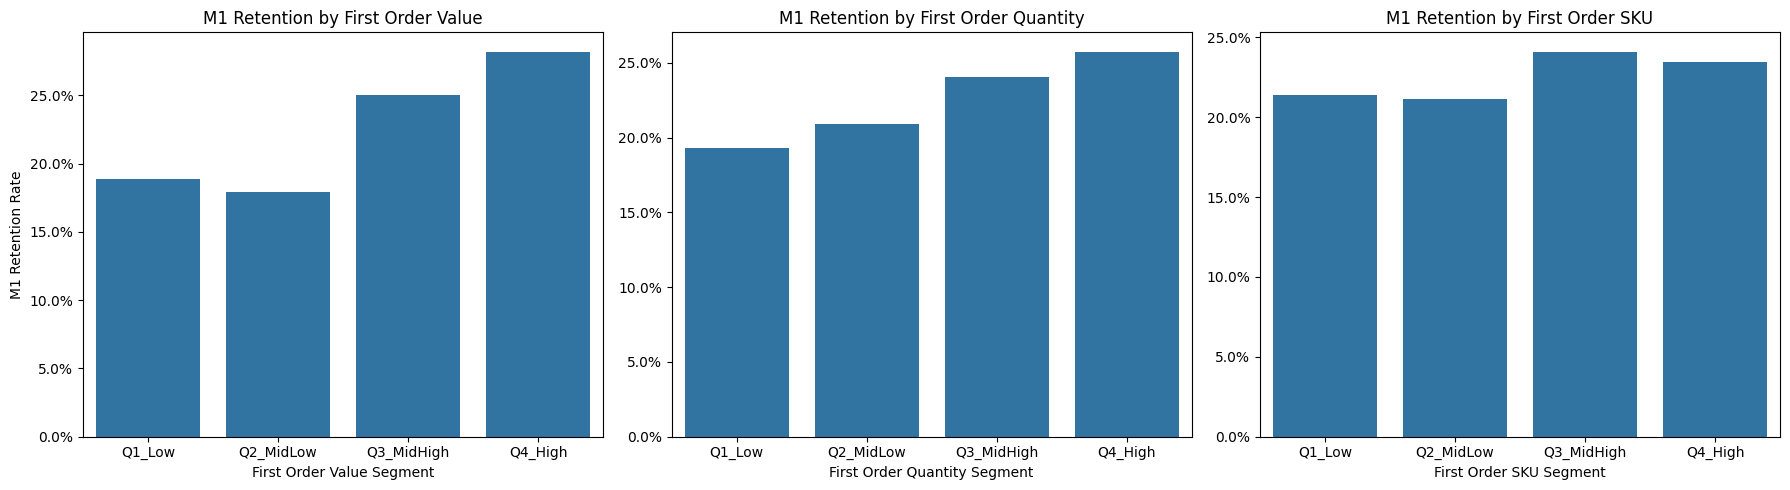

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # 1행 3열로 배치

# 1. 총 구매 금액(Value)
sns.barplot(
    data=customer_h1_qcut,
    x='Value_Q',
    y='M1_Retention',
    order=['Q1_Low', 'Q2_MidLow', 'Q3_MidHigh', 'Q4_High'],
    errorbar=None,
    ax=axes[0]
)
axes[0].set_title('M1 Retention by First Order Value')
axes[0].set_xlabel('First Order Value Segment')
axes[0].set_ylabel('M1 Retention Rate')
axes[0].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))

# 2. 총 수량(Quantity)
sns.barplot(
    data=customer_h1_qcut,
    x='Qty_Q',
    y='M1_Retention',
    order=['Q1_Low', 'Q2_MidLow', 'Q3_MidHigh', 'Q4_High'],
    errorbar=None,
    ax=axes[1]
)
axes[1].set_title('M1 Retention by First Order Quantity')
axes[1].set_xlabel('First Order Quantity Segment')
axes[1].set_ylabel('')
axes[1].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))

# 3. SKU
sns.barplot(
    data=customer_h1_qcut,
    x='SKU_Q',
    y='M1_Retention',
    order=['Q1_Low', 'Q2_MidLow', 'Q3_MidHigh', 'Q4_High'],
    errorbar=None,
    ax=axes[2]
)
axes[2].set_title('M1 Retention by First Order SKU')
axes[2].set_xlabel('First Order SKU Segment')
axes[2].set_ylabel('')
axes[2].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

#### (4) 통계 검정

- 검정 방법: 카이제곱 독립성 검정 (Chi-square test)
- 검정 목적: 첫 주문 금액 구간과 M1 리텐션 발생 여부 간의 통계적 연관성 검증
- 귀무가설(H₀): 첫 주문 금액 구간과 M1 리텐션은 서로 독립이다
- 대립가설(H₁): 첫 주문 금액 구간과 M1 리텐션은 서로 독립이 아니다

In [57]:
customer_h1_qcut.head()

,CustomerID,M1_Retention,first_order_value,first_order_quantity,first_order_sku,High_99_value,High_99_qty,High_99_sku,Value_Q,Qty_Q,SKU_Q
0,17850,0,139.12,40,7,False,False,False,Q1_Low,Q1_Low,Q1_Low
1,13047,0,278.73,83,12,False,False,False,Q2_MidLow,Q1_Low,Q2_MidLow
2,12583,1,855.86,449,20,False,False,False,Q4_High,Q4_High,Q3_MidHigh
3,13748,0,204.00,80,1,False,False,False,Q2_MidLow,Q1_Low,Q1_Low
4,15100,1,350.40,32,1,False,False,False,Q3_MidHigh,Q1_Low,Q1_Low


In [58]:
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

def chi_square_with_cramers_v(df, feature_col, target_col='M1_Retention'):

    # (1) 교차표 생성
    contingency_table = pd.crosstab(df[feature_col], df[target_col])

    # (2) 리텐션율 계산
    retention_rate = contingency_table.div(
        contingency_table.sum(axis=1), axis=0
    )[1]

    # (3) 카이제곱 검정
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    # (4) Cramer's V 계산
    n = contingency_table.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))

    print(f"\n===== {feature_col} =====")
    print("Chi-square:", round(chi2, 3))
    print("p-value:", p_value)
    print("df:", dof)
    print("Cramer's V:", round(cramers_v, 3))
    print("\n[Retention Rate by Group]")
    print(retention_rate.round(3))

    return {
        'Feature': feature_col,
        'Chi2': chi2,
        'p_value': p_value,
        'df': dof,
        'Cramers_V': cramers_v
    }

In [59]:
def run_chi_square_batch(df, feature_list, target_col='M1_Retention'):

    results = []

    for feature in feature_list:
        result = chi_square_with_cramers_v(df, feature, target_col)
        results.append(result)

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(
        by='Cramers_V', ascending=False
    ).reset_index(drop=True)

    return results_df

In [60]:
features = ['Value_Q', 'Qty_Q', 'SKU_Q']

results_df = run_chi_square_batch(customer_h1_qcut, features)


===== Value_Q =====
Chi-square: 45.501
p-value: 7.241860160788924e-10
df: 3
Cramer's V: 0.102

[Retention Rate by Group]
Value_Q
Q1_Low        0.189
Q2_MidLow     0.179
Q3_MidHigh    0.250
Q4_High       0.282
Name: 1, dtype: float64

===== Qty_Q =====
Chi-square: 16.037
p-value: 0.001114146258122493
df: 3
Cramer's V: 0.061

[Retention Rate by Group]
Qty_Q
Q1_Low        0.193
Q2_MidLow     0.209
Q3_MidHigh    0.240
Q4_High       0.258
Name: 1, dtype: float64

===== SKU_Q =====
Chi-square: 4.085
p-value: 0.25247131451634236
df: 3
Cramer's V: 0.031

[Retention Rate by Group]
SKU_Q
Q1_Low        0.214
Q2_MidLow     0.211
Q3_MidHigh    0.241
Q4_High       0.234
Name: 1, dtype: float64


- 카이제곱 독립성 검정 결과
  - 첫 주문 금액 (Value_Q)
    - 첫 주문 금액 구간과 M1 리텐션 발생 여부 간 통계적으로 유의미한 연관성 확인 (χ² = 43.64, df = 3, p < 0.001).
    - Cramer's V 지수는 0.10으로, 일반적인 기준에서 약한(weak) 수준의 연관 강도
    - 이는 첫 주문 금액 구간과 M1 리텐션 간에 통계적으로는 유의미하지만, 단독으로 강한 설명력을 가지는 변수라기보다는 리텐션을 설명하는 여러 초기 구매 행동 요인 중 하나임을 시사
  - 첫 주문 수량 (Qty_Q)
    - 첫 주문 수량 구간 역시 M1 리텐션과 통계적으로 유의미한 연관성 확인 (χ² = 15.04, df = 3, p = 0.0018)
    - 그러나 Cramer's V 값은 0.059로, 매우 약한 수준의 연관 강도
    - 이는 수량 또한 리텐션과 관련은 있으나, 영향력의 크기는 제한적임을 의미
  - 첫 주문 상품 다양성 (SKU_Q)
    - 첫 주문 상품 다양성 구간은 M1 리텐션과 통계적으로 유의미한 연관성을 보이지 않음 (χ² = 3.66, df = 3, p = 0.30).
    - Cramer's V 값 역시 0.029로 매우 낮아, 실질적인 연관성이 크지 않은 것으로 해석

### [2] 분석 결과 요약
- Driver 강도 비교 (Cramer's V 기준)
  - Value_Q (0.100): 가장 높은 연관 강도
  - Qty_Q (0.059) : 약한 연관성
  - SKU_Q (0.029) : 유의하지 않음

  : 세 가지 초기 구매 행동 변수 중, 첫 주문 금액이 상대적으로 가장 중요한 리텐션 관련 신호로 나타남

- 패턴 요약 (Value_Q 기준)
  - Low(리텐션 약 19%) → Mid-Low(약 18%): 소폭 하락 (유의미한 차이 없음)
  - Mid-Low(약 18%) → Mid-High(약 25%): 명확한 상승
  - Mid-High(약 25%) → High(약 28%): 추가 상승

  : 첫 주문 금액이 일정 수준 이상일 때부터 M1 리텐션이 뚜렷하게 증가
  
  : 이는 단순한 선형 증가라기보다는 일정 금액 구간 이상에서 리텐션이 개선되는    임계값(threshold) 효과 가능성을 시사

### [3] 가설 1 결론
  - 첫 주문 총 결제 금액을 제외한 다른 변수들은 유의하지만 연관 강도가 약하거나 유의미하지 못한 것으로 나타남
  - 초기 구매 행동 중에서는 구매 금액 규모가 수량이나 상품 다양성보다 상대적으로 더 중요한 리텐션 관련 신호일 가능성이 있음
  - 첫 주문 총 결제 금액이 높은 고객일수록 M1 리텐션이 전반적으로 높은 경향을 보임
  - 특히 상위 50% 금액 구간(Mid-High, High)의 M1 리텐션은 하위 구간 대비 약 1.4~1.5배 수준
  - 첫 주문 금액 수준이 초기 재구매 전환에 유의미한 영향을 미칠 가능성을 시사
  - 다만 본 분석은 상관관계 기반 분석이므로,첫 주문 금액이 리텐션을 직접적으로 "유발"한다고 단정하기보다는 두 변수 간 통계적으로 유의한 연관성이 존재함을 확인한 결과로 해석하는 것이 타당

### [6.2.2] 가설 2 - 초기 구매 빈도 가설 (초기 구매 빈도 M1 리텐션)
: 첫 구매 이후 초기 기간(M0) 동안 구매 빈도가 높은 고객일수록, 이후 월(M1) 리텐션이 높을 것이다.
- 초기 기간 내 재구매 경험 여부가 이후 재방문 가능성과 연관 여부 분석 가설
- 단순 구매 규모(금액, 수량)보다 행동 반복성(Repeat Behavior)이 더 중요한 신호일 가능성 검증

### [1] 가설 검증 절차

#### (1) 데이터 정의
  - 분석 대상: Cohort 분석이 가능한 구매 고객 (CohortIndex ≥ 0)
  - 첫 주문 정의: 고객별 CohortIndex = 0 중 최초 Invoice
  - 초기 구매 빈도 정의: 첫 구매월(M0) 동안 고객별 구매 Invoice 횟수 중, 첫 주문을 제외한 추가 구매 횟수
  - 변수 구성
    - M0_Repeat_Purchase_Freq : M0 내 추가 구매 횟수
    - M0_Repeat_Binary : M0 내 재구매 경험 여부 (0 = 없음, 1 = 있음)
  - M1 리텐션 정의: CohortIndex = 1 시점 구매 발생 여부
  - 분석 단위: 고객(CustomerID)

#### (2) Feature 생성
  - M0 기간 내 고객별 추가 구매 횟수 산출
  - 기존 customer_master와 병합하여 가설 2 전용 분석 테이블 구성

In [64]:
# 가설 2 테이블 생성 (customer_h2)

# 고객별 M0 전체 구매 Invoice 수
m0_invoice_cnt = (
    df_c0
    .groupby('CustomerID')['InvoiceNo']
    .nunique()
    .reset_index(name='M0_Total_Invoice')
)

# 첫 주문 제외 → 추가 구매 횟수
m0_invoice_cnt['M0_Repeat_Purchase_Freq'] = (
    m0_invoice_cnt['M0_Total_Invoice'] - 1
).clip(lower=0)

# customer_master 병합
customer_h2 = customer_master.merge(
    m0_invoice_cnt[['CustomerID', 'M0_Repeat_Purchase_Freq']],
    on='CustomerID',
    how='left'
).fillna({'M0_Repeat_Purchase_Freq': 0})

# 이진 변수 생성
customer_h2['M0_Repeat_Binary'] = (
    customer_h2['M0_Repeat_Purchase_Freq'] > 0
).astype(int)

customer_h2.head()

,CustomerID,M1_Retention,M0_Repeat_Purchase_Freq,M0_Repeat_Binary
0,17850,0,33,1
1,13047,0,2,1
2,12583,1,0,0
3,13748,0,0,0
4,15100,1,1,1


#### (3) 기술 통계 및 패턴 확인

- 재구매 횟수별 비율 체크
  - 재구매 횟수 0이 데이터의 대부분을 차지
  - 횟수가 늘어감에 따라 데이터 표본 급격히 감소

In [65]:
customer_h2['M0_Repeat_Purchase_Freq'].value_counts().sort_index()

,count
M0_Repeat_Purchase_Freq,
0,3696
1,486
2,95
3,34
4,14
5,5
7,3
8,1
9,1


- 추가 구매 횟수 구간화 분석
  - 0회에서 1회로 변동될 때 급격히 Retention이 증가함
  - 그 이후는 증가 폭 둔화되어 고빈도는 표본이 적으므로 “임계점(threshold) 효과” 구조로 볼 수 있음
  - 그러므로 이진 분석으로 전환하고자 함

In [66]:
customer_h2['Repeat_Freq_Group'] = pd.cut(
    customer_h2['M0_Repeat_Purchase_Freq'],
    bins=[-1, 0, 1, 2, 5, 999],
    labels=['0회', '1회', '2회', '3~5회', '6회 이상']
)

ret_repeat_group = (
    customer_h2
    .groupby('Repeat_Freq_Group')['M1_Retention']
    .mean()
    .reset_index()
)

ret_repeat_group

/tmp/ipykernel_159/3017623063.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('Repeat_Freq_Group')['M1_Retention']


,Repeat_Freq_Group,M1_Retention
0,0회,0.193452
1,1회,0.351852
2,2회,0.494737
3,3~5회,0.679245
4,6회 이상,0.777778


- 재구매 경험 여부별 M1 리텐션 비교

In [67]:
ret_repeat_binary = (
    customer_h2
    .groupby('M0_Repeat_Binary')['M1_Retention']
    .mean()
    .reset_index()
)

ret_repeat_binary

,M0_Repeat_Binary,M1_Retention
0,0,0.193452
1,1,0.405910


#### (4) 시각화

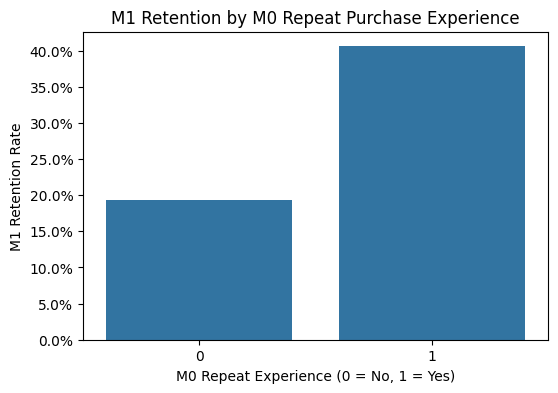

In [68]:
plt.figure(figsize=(6,4))
sns.barplot(
    data=ret_repeat_binary,
    x='M0_Repeat_Binary',
    y='M1_Retention',
    errorbar=None
)

plt.title('M1 Retention by M0 Repeat Purchase Experience')
plt.xlabel('M0 Repeat Experience (0 = No, 1 = Yes)')
plt.ylabel('M1 Retention Rate')
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
plt.show()

#### (5) 통계 검정
- 카이제곱 독립성 검정 (Chi-square test)
  - 귀무가설 (H0)
    - M0 재구매 경험 여부와 M1 리텐션은 서로 독립이다.
  - 대립가설 (H1)
    - M0 재구매 경험 여부와 M1 리텐션은 서로 독립이 아니다.

In [69]:
from scipy.stats import chi2_contingency
import numpy as np

contingency = pd.crosstab(
    customer_h2['M0_Repeat_Binary'],
    customer_h2['M1_Retention']
)

chi2, p_value, dof, expected = chi2_contingency(contingency)

n = contingency.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))

chi2, p_value, dof, cramers_v

(np.float64(140.59164189201846),
 np.float64(1.9762287695787733e-32),
 1,
 np.float64(0.18000514825293554))

### [2] 통계 검정 결과
- 패턴 요약
  - M0 기간 내 재구매 경험이 없는 고객(0회)의 M1 리텐션은 낮은 수준
  - 재구매 경험이 있는 고객(1회 이상)의 M1 리텐션은 유의하게 높게 나타남
    - 특히 0회 → 1회로 변화할 때 리텐션이 가장 크게 상승
    - 1회 이상 추가 구매 횟수 증가에 따른 리텐션 증가는 상대적으로 둔화
  - 이는 단순한 선형 증가 구조라기보다는 [재구매 경험 여부]에서 리텐션이 크게 구분되는 임계값(threshold) 효과 구조를 시사

### [3] 가설 2 결론
- 첫 구매 이후 초기 기간(M0) 내 재구매 경험 여부는 M1 리텐션과 통계적으로 유의미한 연관성을 가지는 것으로 확인 (χ² = 140.59, df = 1, p < 0.001)
- Cramer's V 지수는 0.18로 나타났으며, 일반적인 기준에 따라 약한(weak)~중간(moderate)에 가까운 수준의 연관 강도를 보임
- 가설 1에서 확인된 구매 규모(총 결제 금액, 수량, SKU 수) 변수들과 비교할 때, 초기 구매 빈도 변수는 더 높은 연관 강도를 보임
- 이는 단순한 구매 규모보다 짧은 기간 내 반복 구매 행동이 고객의 서비스 적합성 및 관여도(engagement)를 보다 직접적으로 반영하는 신호일 가능성 시사
- 다만 본 분석은 카이제곱 독립성 검정을 기반으로 한 상관관계 분석이므로, 초기 재구매 경험이 M1 리텐션을 직접적으로 유발한다고 단정하기보다는 두 변수 간 통계적으로 유의한 연관성이 존재함을 확인한 결과로 해석하는 것이 타당함

### [6.2.3] 가설 3 - 카테고리 기반 가설 (특정 카테고리와 M1 리텐션)
: 초기 기간(M0) 동안 구매한 상품의 카테고리에 따라, 이후 월(M1) 리텐션에는 유의미한 차이가 있을 것이다.

### [1] 가설 검증 절차

#### (1) 데이터 정의
  - 분석 대상: Cohort 분석이 가능한 구매 고객 (CohortIndex ≥ 0)
  - 초기 구매 카테고리 정의
    - M0 기간 동안 고객이 구매한 전체 상품의 카테고리
    - 고객 기준으로 카테고리 구매 비중(수량 기준) 으로 정의
      (카테고리 경험 구성 = category x quantity)
  - M1 리텐션 정의: CohortIndex = 1 시점 구매 발생 여부
  - 분석 단위: 고객(CustomerID)

#### (2) 분석 방법
  - 고객별 M0 기간 내 카테고리 구매 구성 비율 산출 (B2B 제외 : 수량 1000개 이상)
  - 카테고리별 M1 리텐션 비율 비교
  - Retained vs Churned 그룹 간 카테고리 평균 비율 비교
  - 카테고리별 평균 차이(retention gap) 시각화
  - 두 그룹 간 평균 차이의 통계적 유의성 검정 (Welch 독립표본 t-검정)


#### (3) M0 기간 카테고리 비중 확인 및 M1 리텐션 비율 비교
- 고객별 M0 기간 내 카테고리 구매 구성 비율 산출 (B2B 제외 : 수량 1000개 이상)
- 카테고리별 M1 리텐션 비율 비교
- Retained vs Churned 그룹 간 카테고리 평균 비율 비교

In [70]:
# B2B 주문 데이터 분리 분석

# M0 기간 수량 구성 확인

m0_invoice_qty = (
    df_c0
    .groupby(['CustomerID','InvoiceNo'])['Quantity']
    .sum()
    .reset_index(name='invoice_qty')
)

m0_invoice_qty['invoice_qty'].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.96, 0.97, 0.98, 0.99]
)

,invoice_qty
count,5326.000000
mean,250.360308
std,1095.050931
min,1.000000
50%,143.500000
75%,266.000000
90%,476.000000
95%,678.750000
96%,767.000000
97%,901.250000


In [71]:
# 벌크 주문 필터링
# 수량 1000개 이상은 B2B로 판단 -> 98% 에서 99%로 변경시 급격한 수량 변화 발생하므로 98%를 기준으로 1000개를 B2B 수량 기준으로 정함

bulk_invoice = m0_invoice_qty[
    m0_invoice_qty['invoice_qty'] >= 1000
][['CustomerID','InvoiceNo']]

# df_c0에서 벌크 주문 제외
df_c0_filtered = df_c0.merge(
    bulk_invoice,
    on=['CustomerID','InvoiceNo'],
    how='left',
    indicator=True
)

df_c0_filtered = df_c0_filtered[
    df_c0_filtered['_merge'] == 'left_only'
].copy()

df_c0_filtered.drop(columns=['_merge'], inplace=True)

In [72]:
# 고객별 카테고리 경험량(카테고리 x 수량)
cust_cat_qty = (
    df_c0_filtered
    .groupby(['CustomerID','category'])['Quantity']
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)
cust_cat_qty

category,CustomerID,Bags & Carry,Home Decor,Kitchenware,Lighting,Other,Storage & Organization,Tableware
0,12347,4,66,0,36,206,7,0
1,12349,8,69,69,24,424,18,19
2,12350,24,12,0,0,161,0,0
3,12352,12,0,12,8,63,0,3
4,12353,0,0,20,0,0,0,0
...,...,...,...,...,...,...,...,...
4254,18280,3,3,0,2,25,6,6
4255,18281,10,0,0,0,44,0,0
4256,18282,0,6,19,0,2,48,0
4257,18283,29,4,15,9,68,1,2


In [73]:
# 고객별 카테고리 경험량을 비율로 변환
cust_cat_qty['total_qty'] = cust_cat_qty.drop(columns='CustomerID').sum(axis=1)

cust_cat_ratio = cust_cat_qty.copy()

cat_cols = cust_cat_ratio.columns.drop(['CustomerID','total_qty'])

cust_cat_ratio[cat_cols] = cust_cat_ratio[cat_cols].div(
    cust_cat_ratio['total_qty'], axis=0
)

cust_cat_ratio.head()

category,CustomerID,Bags & Carry,Home Decor,Kitchenware,Lighting,Other,Storage & Organization,Tableware,total_qty
0,12347,0.012539,0.206897,0.000000,0.112853,0.645768,0.021944,0.000000,319
1,12349,0.012678,0.109350,0.109350,0.038035,0.671949,0.028526,0.030111,631
2,12350,0.121827,0.060914,0.000000,0.000000,0.817259,0.000000,0.000000,197
3,12352,0.122449,0.000000,0.122449,0.081633,0.642857,0.000000,0.030612,98
4,12353,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,20


In [74]:
# M1 Retention 병합
analysis_cat = cust_cat_ratio.merge(
    customer_master[['CustomerID','M1_Retention']],
    on='CustomerID',
    how='left'
)

analysis_cat['M1_Retention'] = analysis_cat['M1_Retention'].fillna(0).astype(int)
analysis_cat.head()

,CustomerID,Bags & Carry,Home Decor,Kitchenware,Lighting,Other,Storage & Organization,Tableware,total_qty,M1_Retention
0,12347,0.012539,0.206897,0.000000,0.112853,0.645768,0.021944,0.000000,319,1
1,12349,0.012678,0.109350,0.109350,0.038035,0.671949,0.028526,0.030111,631,0
2,12350,0.121827,0.060914,0.000000,0.000000,0.817259,0.000000,0.000000,197,0
3,12352,0.122449,0.000000,0.122449,0.081633,0.642857,0.000000,0.030612,98,1
4,12353,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,20,0


In [75]:
# 리텐션 그룹 간 경험 차이 확인
retention_profile = analysis_cat.groupby('M1_Retention')[cat_cols].mean()
retention_profile

,Bags & Carry,Home Decor,Kitchenware,Lighting,Other,Storage & Organization,Tableware
M1_Retention,,,,,,,
0,0.075752,0.129738,0.07111,0.071735,0.608263,0.007802,0.035600
1,0.078837,0.130195,0.07137,0.074004,0.594608,0.008420,0.042566


In [76]:
# 차이 크기 보기 (Retention - Churn)
retention_gap = retention_profile.loc[1] - retention_profile.loc[0]
retention_gap.sort_values(ascending=False)

,0
Tableware,0.006966
Bags & Carry,0.003084
Lighting,0.002269
Storage & Organization,0.000619
Home Decor,0.000457
Kitchenware,0.000260
Other,-0.013655


#### (4) 시각화
 - 카테고리별 평균 차이(retention gap) 시각화

<Axes: >

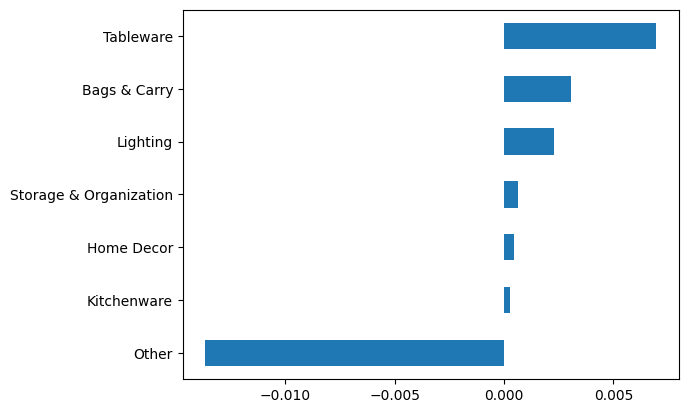

In [77]:
# 시각화
retention_gap.sort_values().plot(kind='barh')

#### (5) 통계 검정
- Welch 독립표본 t-검정 (두 그룹 간 평균 차이의 통계적 유의성 검정)
  - 검정 목적
    - M1 리텐션 여부에 따라 M0 기간 내 카테고리 구매 비율의 평균이 통계적으로 유의하게 다른지 검정
  - 귀무가설 (H0)
    - Retained 그룹과 Churned 그룹 간 해당 카테고리 구매 비율의 평균 차이는 없다. (초기 M0 구매 카테고리 구성과 M1 Retention 간 통계적으로 유의한 차이는 없다)
  - 대립가설 (H1)
    - Retained 그룹과 Churned 그룹 간 해당 카테고리 구매 비율의 평균 차이는 있다. (초기 M0 구매 카테고리 구성과 M1 Retention 간 통계적으로 유의한 차이가 존재한다)

In [78]:
# 통계 검정
from scipy.stats import ttest_ind

retained = analysis_cat[analysis_cat['M1_Retention'] == 1]
churned = analysis_cat[analysis_cat['M1_Retention'] == 0]

for c in cat_cols:
    stat, p = ttest_ind(retained[c], churned[c], equal_var=False)
    print(c, round(p, 4))

Bags & Carry 0.6061
Home Decor 0.9418
Kitchenware 0.9551
Lighting 0.6564
Other 0.152
Storage & Organization 0.6952
Tableware 0.0794


### [2] 통계 검정 결과
- 패턴 요약
  - M0 기간 내 카테고리 구매 구성 비율은 Retained 그룹과 Churned 그룹 간 전반적으로 유의한 평균 차이를 보이지 않음
    - 모든 카테고리에서 p-value가 0.05를 초과(통계적으로 유의한 차이는 확인되지 않음)
    - Tableware 카테고리의 경우 p=0.0794로 가장 낮은 값을 보였으나, 통계적 유의수준(0.05)에는 미치지 못함
    - Other 카테고리는 Retention 그룹에서 평균 비율이 다소 낮게 나타났으나(p=0.152), 역시 유의하지 않음
  - 전반적으로 단일 카테고리 비율만으로는 M1 리텐션을 설명할 수 있는 뚜렷한 통계적 차이가 확인되지 않음

### [3] 가설 3 결론
- Welch 독립표본 t-검정 결과, 모든 카테고리의 p-value가 0.05를 초과
- 즉, M0 기간 내 카테고리 구매 구성 비율은 Retained 그룹과 Churned 그룹 간 통계적으로 유의한 평균 차이를 보이지 않음
- 따라서,초기(M0) 구매 카테고리 구성 비율은 단독 변수로서 M1 리텐션에 영향을 끼치지 못함
  - 전체 구매 규모, 재구매 경험 여부, 구매 빈도 등의 복합적인 구매 패턴 등과 결합된 다변량 구조일 가능성을 시사
- 가설 3은 단변량 수준에서는 지지되지 않았다.

### [6.3] 다변량 분석
- 단변량 분석으로 각 가설 변수와 M1 Retention 간의 개별적인 연관성 검증 진행하였으나 변수 간 상호 영향을 통제하지 않은 상태에서의 관계만 알수 있음
- M1 Retention에 독립적으로 영향을 미치는 핵심 요인을 식별하기 위해 여러 초기 구매 행동 변수를 동시에 투입한 다변량 분석이 필요
- 다변량 분석에는 종속변수가 이진형(0/1)인 점을 고려하여 로지스틱 회귀(Logistic Regression) 적용



### [6.3.1] 로지스틱 회귀 분석
#### (1) 모델 설계
- 종속변수
  - M1_Retention
    - 1 = M1 기간 내 재구매 발생 (Retained)
    - 0 = M1 기간 내 재구매 미발생 (Churned)
- 독립변수
  - 첫 구매 강도 변수 (가설 1)
    - First_Order_Value (첫 구매 금액)
    - First_Order_Quantity (첫 구매 수량)
    - First_Order_SKU (첫 구매 상품 다양성)
  - 초기 구매 빈도 변수 (가설 2)
    - M0_Repeat_Binary (M0 기간 내 재구매 경험 여부, 0/1)
  - 초기 구매 카테고리 변수 (가설 3)
    - M0 기간 내 카테고리 구매 비율 변수들
      - Bags & Carry
      - Home Decor
      - Kitchenware
      - Lighting
      - Other
      - Storage & Organization
      - Tableware

####

#### (2) 로지스틱 회귀 모델 용 통합 테이블 설계
- 종속변수는 이진형이므로 로지스틱 회귀 적용
- 카테고리 변수는 구매 구성 비율(0~1) 형태로 투입
- 첫 구매 금액의 경우 분포 왜곡 가능성을 고려하여 log 변환 여부를 검토
- 모든 독립변수는 동시에 투입하여 각 변수의 독립적 영향력을 추정

In [79]:
# 최종 모델용 통합 테이블 설계

analysis_base = (
    customer_master
    .merge(
        first_order_features,
        on='CustomerID',
        how='left'
    )
    .merge(
        m0_invoice_cnt[['CustomerID','M0_Repeat_Purchase_Freq']],
        on='CustomerID',
        how='left'
    )
)

analysis_base['M0_Repeat_Purchase_Freq'] = (
    analysis_base['M0_Repeat_Purchase_Freq']
    .fillna(0)
)

analysis_base['M0_Repeat_Binary'] = (
    analysis_base['M0_Repeat_Purchase_Freq'] > 0
).astype(int)

analysis_base.head()

,CustomerID,M1_Retention,first_order_value,first_order_quantity,first_order_sku,M0_Repeat_Purchase_Freq,M0_Repeat_Binary
0,17850,0,139.12,40,7,33,1
1,13047,0,278.73,83,12,2,1
2,12583,1,855.86,449,20,0,0
3,13748,0,204.00,80,1,0,0
4,15100,1,350.40,32,1,1,1


In [80]:
# 카테고리 비율 DF와 merge
analysis_model = analysis_base.merge(
    analysis_cat,
    on=['CustomerID','M1_Retention'],
    how='inner'
)

analysis_model.head()

,CustomerID,M1_Retention,first_order_value,first_order_quantity,first_order_sku,M0_Repeat_Purchase_Freq,M0_Repeat_Binary,Bags & Carry,Home Decor,Kitchenware,Lighting,Other,Storage & Organization,Tableware,total_qty
0,17850,0,139.12,40,7,33,1,0.034622,0.107328,0.00000,0.130410,0.727640,0.0,0.000000,1733
1,13047,0,278.73,83,12,2,1,0.000000,0.316832,0.09901,0.000000,0.584158,0.0,0.000000,101
2,12583,1,855.86,449,20,0,0,0.204900,0.000000,0.00000,0.053452,0.648107,0.0,0.093541,449
3,13748,0,204.00,80,1,0,0,0.000000,0.000000,0.00000,0.000000,1.000000,0.0,0.000000,80
4,15100,1,350.40,32,1,1,1,0.000000,0.000000,0.00000,0.000000,1.000000,0.0,0.000000,64


In [81]:
# 가설3 다중 공선성을 제거하기 위한 [other] 컬럼 drop
analysis_model = analysis_model.drop(columns=['Other'])

# 필요 없는 컬럼 제거
analysis_model = analysis_model.drop(columns=['CustomerID','total_qty'])

# 다른 변수와 절대값 차이가 큰 금액 로그 변환(first_order_value 로그 변환)
analysis_model['log_first_order_value'] = np.log1p(
    analysis_model['first_order_value']
)

analysis_model = analysis_model.drop(columns=['first_order_value'])

analysis_model.head()

,M1_Retention,first_order_quantity,first_order_sku,M0_Repeat_Purchase_Freq,M0_Repeat_Binary,Bags & Carry,Home Decor,Kitchenware,Lighting,Storage & Organization,Tableware,log_first_order_value
0,0,40,7,33,1,0.034622,0.107328,0.00000,0.130410,0.0,0.000000,4.942499
1,0,83,12,2,1,0.000000,0.316832,0.09901,0.000000,0.0,0.000000,5.633825
2,1,449,20,0,0,0.204900,0.000000,0.00000,0.053452,0.0,0.093541,6.753275
3,0,80,1,0,0,0.000000,0.000000,0.00000,0.000000,0.0,0.000000,5.323010
4,1,32,1,1,1,0.000000,0.000000,0.00000,0.000000,0.0,0.000000,5.861925


#### (3) 다중공선성(VIF) 체크

In [82]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = analysis_model.drop(columns=['M1_Retention'])

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif.sort_values("VIF", ascending=False)

,Variable,VIF
10,log_first_order_value,6.602768
1,first_order_sku,2.820401
0,first_order_quantity,2.426668
3,M0_Repeat_Binary,1.727139
5,Home Decor,1.664493
2,M0_Repeat_Purchase_Freq,1.545028
6,Kitchenware,1.378332
4,Bags & Carry,1.323561
7,Lighting,1.293508
9,Tableware,1.159261


- 다중 공선성(VIF) 체크 결과
| 변수                    | VIF  | 해석           |
| --------------------- | ---- | ------------ |
| log_first_order_value | 6.60 | 약간 높지만 허용 가능 |
| 나머지 변수                | 1~3  | 매우 안정적       |


  - 모든 독립변수는 일반적으로 사용하는 기준(VIF < 10) 내에 있음
  - log_first_order_value는 다른 구매 강도 변수(수량, SKU)와의 상관관계로 인해 VIF가 상대적으로 높게 나타났으나, 제거 필요한 수준은 아님
  - 따라서 모든 변수를 유지한 상태에서 로지스틱 회귀 분석 진행하기로 결정

#### (4) 로지스틱 회귀 분석

In [83]:
import statsmodels.api as sm

# -------------------------
# 1. X, y 분리
# -------------------------
X = analysis_model.drop(columns=['M1_Retention'])
y = analysis_model['M1_Retention']

# 상수항 추가
X = sm.add_constant(X)

# -------------------------
# 2. 로지스틱 회귀 실행
# -------------------------
logit_model = sm.Logit(y, X)
result = logit_model.fit()

# 결과 요약 출력
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.514353
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           M1_Retention   No. Observations:                 4259
Model:                          Logit   Df Residuals:                     4247
Method:                           MLE   Df Model:                           11
Date:                Wed, 04 Mar 2026   Pseudo R-squ.:                 0.03723
Time:                        09:58:15   Log-Likelihood:                -2190.6
converged:                       True   LL-Null:                       -2275.3
Covariance Type:            nonrobust   LLR p-value:                 1.548e-30
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -3.0782      0.355     -8.666      0.000      -3.774   

In [84]:
# Odds Ratio + 신뢰구간 정리

# Odds Ratio 계산
params = result.params
conf = result.conf_int()
conf['OR'] = params
conf.columns = ['2.5%', '97.5%', 'coef']

# OR 변환
odds_ratio = np.exp(conf)

odds_ratio

,2.5%,97.5%,coef
const,0.022952,0.092361,0.046042
first_order_quantity,0.999441,1.000187,0.999814
first_order_sku,0.996418,1.004194,1.000299
M0_Repeat_Purchase_Freq,1.046377,1.434810,1.225297
M0_Repeat_Binary,1.557470,2.769637,2.076927
Bags & Carry,0.815734,2.081690,1.303113
Home Decor,0.821467,2.013307,1.286027
Kitchenware,0.581610,1.942396,1.062882
Lighting,0.736417,2.066820,1.233710
Storage & Organization,0.232344,9.056737,1.450612


In [85]:
# 로지스틱 회귀 분석 결과
summary_table = pd.DataFrame({
    'Coefficient': result.params,
    'Odds_Ratio': np.exp(result.params),
    'P_value': result.pvalues
})

summary_table.sort_values('Odds_Ratio', ascending=False)

,Coefficient,Odds_Ratio,P_value
Tableware,0.786839,2.196442,1.811764e-02
M0_Repeat_Binary,0.730889,2.076927,6.457400e-07
Storage & Organization,0.371985,1.450612,6.905771e-01
log_first_order_value,0.279789,1.322851,3.425893e-05
Bags & Carry,0.264756,1.303113,2.679545e-01
Home Decor,0.251558,1.286027,2.713311e-01
Lighting,0.210026,1.233710,4.249975e-01
M0_Repeat_Purchase_Freq,0.203183,1.225297,1.164041e-02
Kitchenware,0.060984,1.062882,8.428575e-01
first_order_sku,0.000299,1.000299,8.802849e-01


#### (3) 해석 및 가설별 영향력 평가
- 모델 전체 적합도
  - 모델은 통계적으로 유의, 다만 설명력은 높지 않음 (행동 데이터 기반 모델에서 흔한 수준)
    - Pseudo R² = 0.037
    - LLR p-value < 0.001
  - 즉, M1 Retention은 단일 요인으로 설명되는 구조가 아님

- 유의 변수 (p < 0.05 기준)
| 변수                          | OR       | p-value | 해석                                 |
| --------------------------- | -------- | ------- | ---------------------------------- |
| **M0_Repeat_Binary**        | **2.08** | <0.001  | M0 재구매 경험 고객은 리텐션 odds 2.08배       |
| **Tableware**               | **2.20** | 0.018   | Other 대비 Tableware 비중이 높을수록 리텐션 상승 |
| **log_first_order_value**   | **1.32** | <0.001  | 첫 구매 금액 증가 시 리텐션 odds 32% 증가       |
| **M0_Repeat_Purchase_Freq** | **1.23** | 0.012   | M0 재구매 빈도 증가 시 리텐션 상승              |


- 가설별 평가
  - 가설 1 (첫 구매 강도)
    - log_first_order_value → 유의 (OR 1.32)
    - quantity, sku → 유의하지 않음
    - 해석
      - 첫 구매의 "금액 규모"는 중요하지만 상품 개수나 SKU 다양성은 독립적 영향이 없음 (H1 부분 채택)
  - 가설 2 (초기 구매 빈도)
    - M0_Repeat_Binary → OR 2.08 (강력)
    - M0_Repeat_Purchase_Freq → OR 1.23 (유의)
    - 해석
      - 초기 재구매 경험 자체가 가장 강력한 Driver
      - 특히 "한 번이라도 M0에 다시 구매한 고객은 M1에도 남을 확률이 2배 이상"
      - H2 강력 채택 (가장 강한 가설)
  - 가설 3 (카테고리 구성)
    - 유의한 것은 오직 Tableware (OR 2.20) 나머지 카테고리는 유의하지 않음.
    - 해석
      - 특정 카테고리 효과는 제한적 카테고리 자체보다는 행동 강도/재구매 경험이 더 중요
      - H3 부분 채택 (Tableware만 의미 있음)

### [6.4] 가설별 최종 결론 및 인사이트
### (1) 분석 결론
- M1 Retention에 가장 큰 영향을 미치는 요인은 초기 재구매 경험이며, 이는 다른 구매 강도 및 카테고리 변수를 통제한 이후에도 가장 높은 영향력을 보였다. 첫 구매 금액은 보조적 요인으로 작용한다. 카테고리 효과는 제한적이다.
  - H1 → 부분 채택 (첫 구매 금액)
  - H2 → 강력 채택 (M0 재구매 경험 여부)
  - H3 → 부분 채택 (Tableware 한정)

### (2) 주요 인사이트
- Insight 1: “초기 재구매 유도”가 핵심 레버
  - M0 재구매 경험 고객은 리텐션 확률 2배 이상 → 첫 30일 내 재구매 캠페인 설계 필요
- Insight 2: 첫 구매 객단가 상승 전략 유효
  - 첫 주문 금액이 증가할수록 리텐션 확률이 유의하게 상승 → 객단가 상승 전략(번들/세트 구성 등) 검토 필요
- Insight 3: 카테고리 전략은 보조적 수단
  - Tableware 카테고리 비중이 높은 고객은 리텐션 확률이 유의하게 높게 나타났으나, 전반적으로 카테고리 변수의 설명력은 제한적이었다.
  - 상품 카테고리 전략보다 초기 행동 유도 전략이 우선순위
- 요약
  - ✔ 첫 달 내 재구매를 반드시 유도해야 함
  - ✔ 첫 구매 객단가를 높이는 전략 유효
  - ✔ Tableware 카테고리는 리텐션 관점에서 전략적 상품군으로 추가 검토 필요

---

## 7. 결론

### 7.1 프로젝트 핵심 결론

- 본 분석은 M1 Retention에 영향을 미치는 초기 구매 행동 요인을 단변량 및 다변량 분석을 통해 검증하였다.
  - 다변량 로지스틱 회귀 분석 결과, M1 Retention의 가장 강력한 선행 요인은 ‘초기 재구매 경험(M0 재구매 여부)’인 것으로 확인되었다. 이는 첫 구매 강도나 카테고리 구성 효과를 통제한 이후에도 가장 높은 영향력을 보였다.

- 즉,
  M1 Retention은 ‘무엇을 샀는가’보다
  ‘**첫 달 안에 다시 샀는가**’에 의해 결정되는 경향이 강하다.
  - 첫 구매 금액은 보조적 요인으로 유의하게 작용하였으며, 카테고리 효과는 일부(Tableware)에 한정되어 나타났다.

### 7.2 전략적 시사점

#### (1) Early Re-purchase 전환 전략이 최우선 과제
- 첫 30일 내 재구매 경험 여부가 리텐션을 2배 이상 차이 나게 만듦
- 따라서 신규 고객 유입 이후의 CRM 설계가 핵심
- 사용 가능한 마케팅 전략
  - 2~3주차 리마인드 캠페인
  - 개인화 추천
  - 재구매 인센티브 제공
- Retention 전략은 “재구매를 기다리는 구조”가 아니라“재구매를 설계하는 구조”로 전환되어야 한다.

#### (2) 첫 구매 객단가 상승 전략의 구조적 효과
- 첫 구매 금액이 높을수록 리텐션 확률이 상승하는 경향이 확인되었다.
- 사용 가능한 마케팅 전략
  - 번들/세트 구성 강화
  - 무료배송 기준 상향 유도
  - 크로스셀 추천 강화
- 단순 매출 증대 목적이 아니라 Retention 관점의 객단가 전략 설계가 필요하다.

### (3) 카테고리 전략은 보조적 수단
- 일부 카테고리(Tableware)에서 유의미한 효과가 나타났으나, 전반적으로 카테고리 자체가 핵심 Driver는 아니었다.
- 따라서 상품 카테고리 중심 전략보다는 행동 기반 Lifecycle 관리 전략이 우선되어야 한다.

### 7.3 분석의 한계 및 향후 과제
#### (1) 분석 한계
- 데이터의 다양성 부재와 단기기간성으로 인해 분석에 한계가 존재
  - Pseudo R²가 낮은 수준 → 리텐션은 다요인적 구조
  - 가격 프로모션, 채널 유입, 고객 세그먼트 등의 변수 미포함
  - 장기 LTV 관점 확장 필요

#### (2) 향후 과제
- Cohort 기반 Retention 분석
- 세그먼트별 로지스틱 모델 비교
- M3/M6 Retention 확장 분석

등을 통해 모델 고도화가 가능하다.